Quanitfy the difference between two ShakeMaps. To be run in env `shakemap`


## Read in and prepare datasets

In [ ]:
#!/usr/bin/env python
"""
Compare two shakemaps.
"""
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from mapio.shake import ShakeGrid

# -------------------------
# USER INPUT
# -------------------------

grid1='/Users/hyin/shakemap_profiles/default/data/us6000jlqa/ffsimmer_pointsource/products/grid.xml'
grid2 = '/Users/hyin/shakemap_profiles/default/data/us6000jlqa/np1/products/grid.xml'
grid3 = '/Users/hyin/shakemap_profiles/default/data/us6000jlqa/shakemap_reproduction/products/grid.xml'
# grid4 = '/Users/hyin/shakemap_profiles/default/data/us7000pn9s/shakemap_reproduction/products/grid.xml'

grid_files = [
    grid1,
    grid2,
    grid3,
    # grid4,
]
labels = ["Unconstrained","NP1","Finite Fault"]

imt = "mmi"
threshold = 1.0
output = f'/Users/hyin/shakemap_profiles/default/data/us6000jlqa/comparison/'




## Load grids

/var/folders/x7/q8y3dbkj0gv831q8bnwtym_c0000gp/T/ipykernel_51587/4088277472.py:91: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.08, 1, 1])


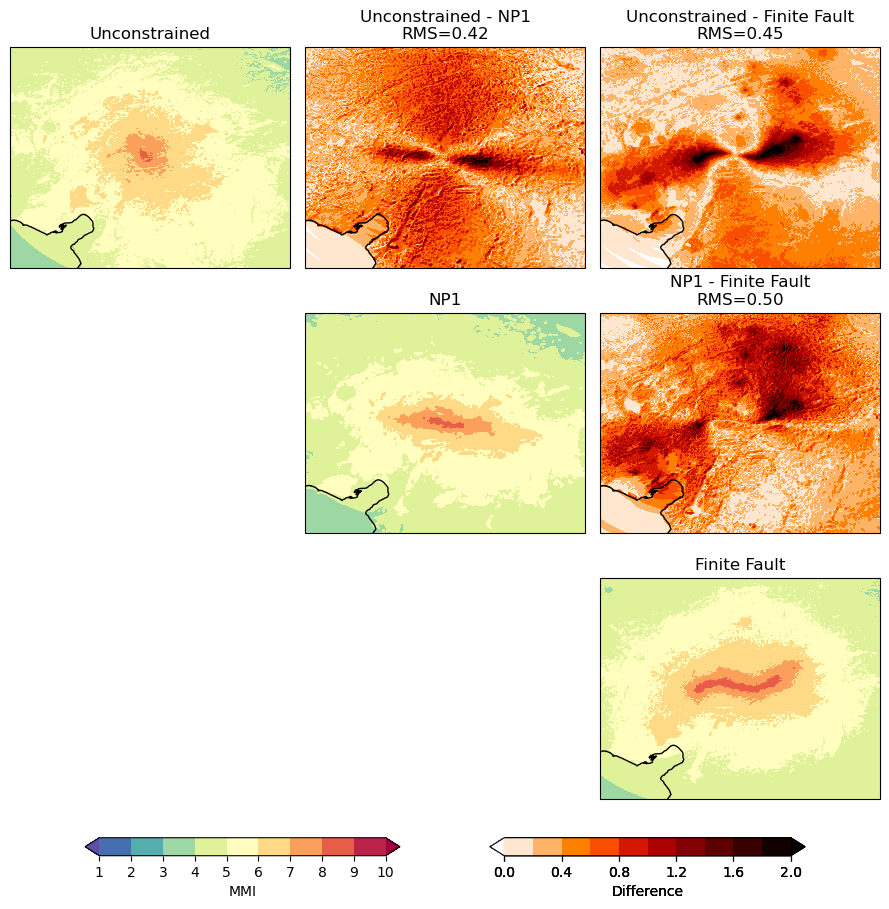

In [7]:

# -------------------------
# LOAD GRIDS
# -------------------------
grids = [ShakeGrid.load(f).getData()[imt] for f in grid_files]
geodicts = [g.getGeoDict() for g in grids]

# Cut grids to their common overlapping region. 
cutdict = geodicts[0]
for gd in geodicts[1:]:
    try:
        cutdict = cutdict.getBoundsWithin(gd)
    except Exception:
        cutdict = gd.getBoundsWithin(cutdict)

# Interpolate all grids to common grid
interp_grids = [g.interpolateToGrid(cutdict) for g in grids]
arrays = [g.getData() for g in interp_grids]

# Coordinates
ny, nx = arrays[0].shape
lats = np.linspace(cutdict.ymin, cutdict.ymax, ny)
lons = np.linspace(cutdict.xmin, cutdict.xmax, nx)

# -------------------------
# PLOTTING
# -------------------------
n = len(arrays)

fig = plt.figure(figsize=(3*n, 3*n))

mmi_levels = np.linspace(1, 10, 10)
diff_levels = np.linspace(0, 2.0, 11)

for i in range(n):
    for j in range(n):
        # Only fill upper triangle (including diagonal)
        if j < i:
            continue

        ax = plt.subplot(n, n, i*n + j + 1, projection=ccrs.PlateCarree())

        if i == j:
            # -------------------------
            # DIAGONAL: original maps
            # -------------------------
            data = arrays[i]

            cs = ax.contourf(
                lons, lats, np.flipud(data),
                mmi_levels, cmap=plt.cm.Spectral_r, extend="both"
            )
            ax.set_title(labels[i])

        else:
            # -------------------------
            # OFF-DIAGONAL: pairwise difference
            # -------------------------
            a = arrays[i].copy()
            b = arrays[j].copy()

            # Shared mask
            mask = (a < threshold) & (b < threshold)
            a[mask] = np.nan
            b[mask] = np.nan

            diff = a - b
            rms = np.sqrt(np.nanmean(diff**2))

            cs = ax.contourf(
                lons, lats, np.flipud(np.abs(diff)),
                diff_levels, cmap=plt.cm.gist_heat_r, extend="both"
            )

            # Diff colorbar
            cax2 = fig.add_axes([0.55, 0.05, 0.35, 0.02])
            fig.colorbar(cs, cax=cax2, orientation="horizontal").set_label("Difference")


            ax.set_title(f"{labels[i]} - {labels[j]}\nRMS={rms:.2f}")

        ax.coastlines()

# -------------------------
# COLORBARS (one for each type)
# -------------------------
# MMI colorbar
cax1 = fig.add_axes([0.1, 0.05, 0.35, 0.02])
fig.colorbar(cs, cax=cax1, orientation="horizontal").set_label("MMI")


plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig(f"{output}comparison_matrix.png", dpi=300)
plt.show()

## Plot a single area-intensity distribution plot

In [12]:
def binned_area(arr, bin_edges, area_grid):
    """
    Compute area within each magnitude bin.

    Parameters
    ----------
    arr : 2D array
        Magnitude (e.g., MMI) grid.
    bin_edges : 1D array
        Bin edges (length N+1 defines N bins).
        Example: np.arange(1.0, 10.5, 0.5)
    area_grid : 2D array
        Per-pixel area (km^2), same shape as arr.

    Returns
    -------
    areas : 1D array
        Area (km^2) in each bin.
    fracs : 1D array
        Fraction of total valid area in each bin.
    total_area : float
        Total valid area (km^2).
    """
    # Handle MaskedArray -> NaN
    # data = arr.filled(np.nan) if np.ma.isMaskedArray(arr) else arr
    data = arr
    finite = np.isfinite(data)

    total_area = area_grid[finite].sum()

    areas = []
    for i in range(len(bin_edges) - 1):
        lo = bin_edges[i]
        hi = bin_edges[i + 1]

        # Left-inclusive, right-exclusive except last bin
        if i == len(bin_edges) - 2:
            mask = finite & (data >= lo) & (data <= hi)
        else:
            mask = finite & (data >= lo) & (data < hi)

        areas.append(area_grid[mask].sum())

    areas = np.array(areas, dtype=float)
    fracs = areas / total_area if total_area > 0 else np.zeros_like(areas)

    return areas, fracs, total_area

area_grid shape: (497, 630)
array shape: (497, 630)


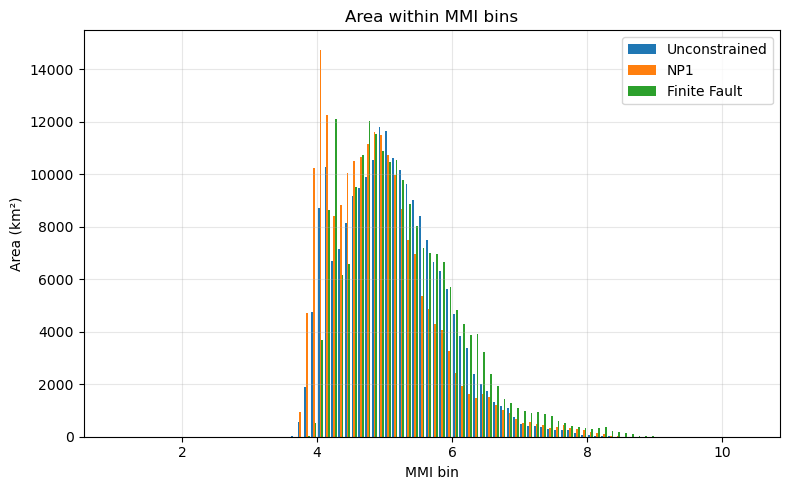

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from mapio.shake import ShakeGrid

# # -------------------------
# # USER INPUT
# # -------------------------
# mag = 7.0
# depth = 10
# imt = "mmi"

# grid_files = [
#     f"/Users/hyin/shakemap_profiles/default/data/synth-ss_us7000pn9s/M{mag}_{depth}km_constrained/products/grid.xml",
#     f"/Users/hyin/shakemap_profiles/default/data/synth-ss_us7000pn9s/M{mag}_{depth}km_unconstrained/products/grid.xml",
#     # add more here
# ]

# labels = [
#     "Constrained",
#     "Unconstrained",
#     # must match grid_files
# ]

# -------------------------
# LOAD + ALIGN GRIDS
# -------------------------
grids = [ShakeGrid.load(f).getData()[imt] for f in grid_files]
geodicts = [g.getGeoDict() for g in grids]

# Find common bounds
cutdict = geodicts[0]
for gd in geodicts[1:]:
    try:
        cutdict = cutdict.getBoundsWithin(gd)
    except Exception:
        cutdict = gd.getBoundsWithin(cutdict)

# Interpolate all grids
interp_grids = [g.interpolateToGrid(cutdict) for g in grids]
arrays = [g.getData() for g in interp_grids]

## Calculate Areas: 
R = 6371  # km
dlat = np.radians(lats[1] - lats[0])
dlon = np.radians(lons[1] - lons[0])

lats_rad = np.radians(lats)
area_per_row = R**2 * dlat * dlon * np.cos(lats_rad)

area_grid = np.repeat(area_per_row[:, np.newaxis], nx, axis=1)

area_grid.shape == arrays[0].shape

# -------------------------
# BINNING
# -------------------------
bin_edges = np.arange(1.0, 10.5, 0.1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

bin_areas = []

print("area_grid shape:", area_grid.shape)
print("array shape:", arrays[0].shape)


for arr in arrays:    
    area, frac, _ = binned_area(arr, bin_edges, area_grid)
    bin_areas.append(area)

bin_areas = np.array(bin_areas)  # shape: (n_grids, n_bins)

# -------------------------
# PLOTTING
# -------------------------
n = len(arrays)
width = (bin_edges[1] - bin_edges[0]) * (0.8 / n)

fig, ax = plt.subplots(figsize=(8, 5))

for i in range(n):
    offset = (i - (n - 1) / 2) * width
    ax.bar(
        bin_centers + offset,
        bin_areas[i],
        width=width,
        label=labels[i]
    )

ax.set_xlabel("MMI bin")
ax.set_ylabel("Area (km²)")
ax.set_title("Area within MMI bins")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig(f"{output}/MMI_binned_area.png", dpi=200)
plt.show()

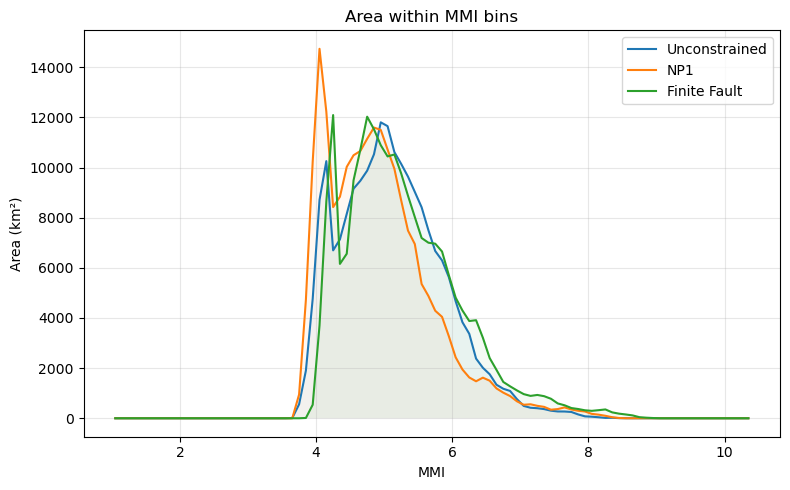

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))

for i in range(n):
    y = bin_areas[i]
    ax.plot(bin_centers, y, label=labels[i])
    ax.fill_between(bin_centers, y, alpha=0.05)

ax.set_xlabel("MMI")
ax.set_ylabel("Area (km²)")
ax.set_title("Area within MMI bins")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig(f"{output}/MMI_area-intensity-dist.png", dpi=200)
plt.show()

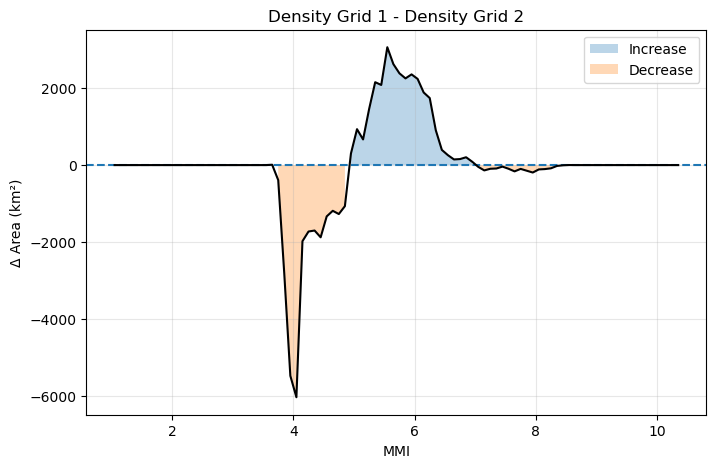

In [15]:
delta = bin_areas[0] - bin_areas[1]  # or any pair

fig, ax = plt.subplots(figsize=(8, 5))

ax.axhline(0, linestyle="--")

ax.plot(bin_centers, delta, color="black")

ax.fill_between(bin_centers, delta, where=delta > 0, alpha=0.3, label="Increase")
ax.fill_between(bin_centers, delta, where=delta < 0, alpha=0.3, label="Decrease")

ax.set_xlabel("MMI")
ax.set_ylabel("Δ Area (km²)")
ax.set_title("Density Grid 1 - Density Grid 2")
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

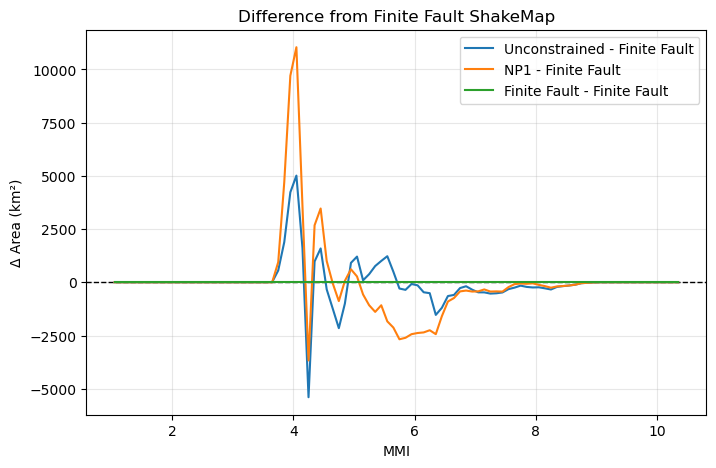

In [19]:
ref_idx = -1  # choose baseline
ref = bin_areas[ref_idx]

fig, ax = plt.subplots(figsize=(8, 5))
ax.axhline(0, linestyle="--", color="k", linewidth=1)

for i in range(len(bin_areas)):
    if i == ref_idx:
        continue
    delta = bin_areas[i] - ref
    ax.plot(bin_centers, delta, label=f"{labels[i]} - {labels[ref_idx]}")

ax.set_xlabel("MMI")
ax.set_ylabel("Δ Area (km²)")
ax.set_title(f"Difference from {labels[ref_idx]} ShakeMap")
ax.legend()
ax.grid(True, alpha=0.3)

plt.savefig(f"{output}/MMI_area-intensity-dist_comparison.png", dpi=200)
plt.show()

## Working code below: 

In [20]:
import numpy as np

# MMI threshold that we'd like to plot and compare
threshold = 1.0

# Extract numeric arrays from the interpolated GridField objects
a1_cut = c1.getData()
a2_cut = c2.getData()

# Sanity check: shapes must match after interpolateToGrid
assert a1_cut.shape == a2_cut.shape, f"Grid shapes differ: {a1_cut.shape} vs {a2_cut.shape}"

# Build a shared mask where BOTH grids are < 4
shared_mask = (a1 < threshold) & (a2 < threshold)

# Set those pixels to NaN in BOTH arrays so they align
a1_cut[shared_mask] = np.nan
a2_cut[shared_mask] = np.nan

# (Optional) If you compute differences, NaNs will line up and propagate:
diff_cut = a1_cut - a2_cut  # will be NaN anywhere shared_mask is True (and anywhere either was NaN)
rms_cut = np.sqrt((a1_cut - a2_cut)**2)

rms = np.sqrt(np.nanmean(diff_cut**2))


NameError: name 'c1' is not defined

## Plot differences with a threshold

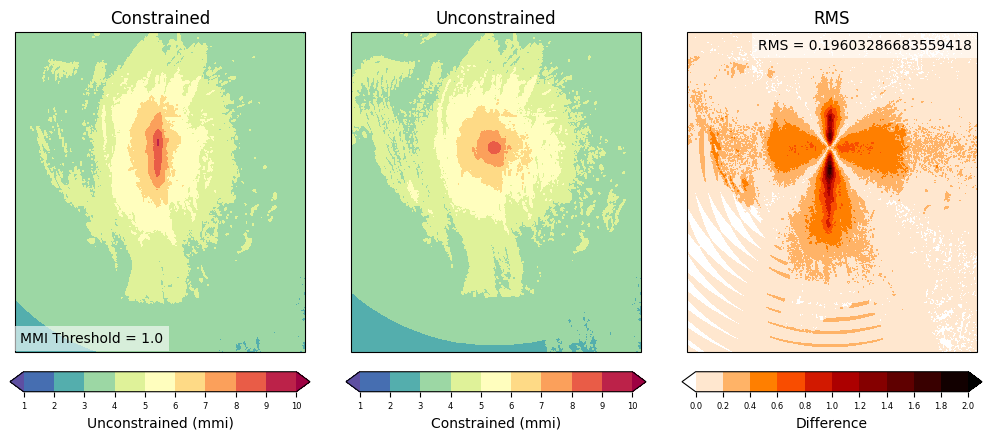

In [29]:
SIZE = (12, 4)
fig = plt.figure(figsize=SIZE)
wid = 0.25
height = 0.8

# Set up contour levels
levels = list(np.linspace(1, 10, 10))
cmap = plt.cm.Spectral_r

## Plot Constrained ShakeMap
# Set axis location
x1 = 0.05
y1 = 0.2
ax1 = plt.axes([x1, y1, wid, height], projection=ccrs.PlateCarree())
cs1 = ax1.contourf(lons, lats, np.flipud(a1_cut), levels, cmap=cmap, extend="both")
ax_cbar1 = plt.axes([x1, y1 - 0.1, wid, 0.05])
cbar1 = fig.colorbar(cs1, cax=ax_cbar1, orientation="horizontal", ticks=levels)
cbar1.ax.tick_params(labelsize=6)
cbar1.ax.set_xlabel(f"Unconstrained ({imt})")
ax1.text(
    0.02, 0.02,          # x, y in axes coordinates
    f"MMI Threshold = {threshold}",
    transform=ax1.transAxes,
    ha="left", va="bottom",
    fontsize=10,
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
)

## Plot Unconstrained ShakeMap
x1 = 0.33
ax2 = plt.axes([x1, y1, wid, height], projection=ccrs.PlateCarree())
cs2 = ax2.contourf(lons, lats, np.flipud(a2_cut), levels, cmap=cmap, extend="both")
ax_cbar2 = plt.axes([x1, y1 - 0.1, wid, 0.05])
cbar2 = fig.colorbar(cs2, cax=ax_cbar2, orientation="horizontal", ticks=levels)
cbar2.ax.tick_params(labelsize=6)
cbar2.ax.set_xlabel(f"Constrained ({imt})")

# Set up contour levels
levels = list(np.linspace(0, 2.0, 11))
# cmap = plt.cm.magma_r
cmap = plt.cm.gist_heat_r

# Plot Difference
x1 = 0.61
y1 = 0.2
ax3 = plt.axes([x1, y1, wid, height], projection=ccrs.PlateCarree())
cs3 = ax3.contourf(lons, lats, np.flipud(rms_cut), levels, cmap=cmap, extend="both")
ax_cbar3 = plt.axes([x1, y1 - 0.1, wid, 0.05])
cbar3 = fig.colorbar(cs3, cax=ax_cbar3, orientation="horizontal", ticks=levels)
cbar3.ax.tick_params(labelsize=6)
cbar3.ax.set_xlabel(f"Difference")

ax3.text(
    0.98, 0.98,          # x, y in axes coordinates
    f"RMS = {rms}",
    transform=ax3.transAxes,
    ha="right", va="top",
    fontsize=10,
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
)

ax1.set_title("Constrained")
ax2.set_title("Unconstrained")
ax3.set_title("RMS")

plt.savefig(f"{output}_rms.png", dpi=300, bbox_inches="tight")



## Area exceedance plot
Plot the area that exceeds each magnitude threshold

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def geodict_bounds(gd):
    """
    Extract xmin, xmax, ymin, ymax, dx, dy from a GeoDict-like object or dict.
    Tries attributes first, falls back to dict keys.
    """
    def get(obj, name, alt=None):
        if hasattr(obj, name):
            return getattr(obj, name)
        if alt is not None and name in obj:
            return obj[name]
        # try common alternatives
        alts = {'xmin':['minx','x_min'], 'xmax':['maxx','x_max'],
                'ymin':['miny','y_min'], 'ymax':['maxy','y_max'],
                'dx':['xdim','xres'], 'dy':['ydim','yres']}
        for k in alts.get(name, []):
            if hasattr(obj, k): return getattr(obj, k)
            if isinstance(obj, dict) and k in obj: return obj[k]
        raise AttributeError(f"Could not find {name} in GeoDict")
    xmin = get(gd, 'xmin')
    xmax = get(gd, 'xmax')
    ymin = get(gd, 'ymin')
    ymax = get(gd, 'ymax')
    dx   = get(gd, 'dx')
    dy   = get(gd, 'dy')
    return xmin, xmax, ymin, ymax, dx, dy

def pixel_area_grid_latlon(shape, gd):
    """
    Approximate per-pixel area (km^2) for an evenly spaced lon/lat raster.
    Assumes PlateCarree (degrees). Area varies with latitude: ~ R^2 * dlon_rad * dlat_rad * cos(lat).
    Returns 2D array of areas matching 'shape'.
    """
    R = 6371.0  # Earth radius in km
    xmin, xmax, ymin, ymax, dx, dy = geodict_bounds(gd)
    ny, nx = shape

    # Build latitude centers from bounds; confirm orientation matches array indexing.
    # Many ShakeMap arrays are displayed origin='lower'. Here we create latitudes from bottom (ymin) to top (ymax).
    lats = np.linspace(ymin + dy/2, ymax - dy/2, ny)  # center of each row
    dlat = np.deg2rad(dy)
    dlon = np.deg2rad(dx)

    # area per row (km^2 per pixel), broadcast to full grid
    row_area = (R * dlat) * (R * dlon) * np.cos(np.deg2rad(lats))  # shape (ny,)
    return np.broadcast_to(row_area[:, None], (ny, nx))  # shape (ny, nx)

def exceedance_area(arr, thresholds, area_grid):
    """
    Area exceedance for array 'arr' at given thresholds.
    Returns area_km2 (per threshold), area_fraction (per threshold), total_area_km2.
    """
    # Handle MaskedArray -> NaN
    data = arr.filled(np.nan) if np.ma.isMaskedArray(arr) else arr
    finite = np.isfinite(data)
    total_area = area_grid[finite].sum()
    areas = np.array([area_grid[finite & (data >= t)].sum() for t in thresholds], dtype=float)
    fracs = areas / total_area if total_area > 0 else np.zeros_like(areas)
    return areas, fracs, total_area

def binned_area(arr, bin_edges, area_grid):
    """
    Compute area within each magnitude bin.

    Parameters
    ----------
    arr : 2D array
        Magnitude (e.g., MMI) grid.
    bin_edges : 1D array
        Bin edges (length N+1 defines N bins).
        Example: np.arange(1.0, 10.5, 0.5)
    area_grid : 2D array
        Per-pixel area (km^2), same shape as arr.

    Returns
    -------
    areas : 1D array
        Area (km^2) in each bin.
    fracs : 1D array
        Fraction of total valid area in each bin.
    total_area : float
        Total valid area (km^2).
    """
    # Handle MaskedArray -> NaN
    # data = arr.filled(np.nan) if np.ma.isMaskedArray(arr) else arr
    data = arr
    finite = np.isfinite(data)

    total_area = area_grid[finite].sum()

    areas = []
    for i in range(len(bin_edges) - 1):
        lo = bin_edges[i]
        hi = bin_edges[i + 1]

        # Left-inclusive, right-exclusive except last bin
        if i == len(bin_edges) - 2:
            mask = finite & (data >= lo) & (data <= hi)
        else:
            mask = finite & (data >= lo) & (data < hi)

        areas.append(area_grid[mask].sum())

    areas = np.array(areas, dtype=float)
    fracs = areas / total_area if total_area > 0 else np.zeros_like(areas)

    return areas, fracs, total_area

# --- Use with your existing objects ---
# After you’ve created c1, c2, and applied your shared NaN mask to a1_cut/a2_cut:
gd = c1.getGeoDict()
area_grid = pixel_area_grid_latlon(a1.shape, gd)

thresholds = np.arange(1.0, 10.01, 0.5)  # choose integer thresholds if preferred

a1_area, a1_frac, a1_total = exceedance_area(a1, thresholds, area_grid)
a2_area, a2_frac, a2_total = exceedance_area(a2, thresholds, area_grid)

print(f"Total valid area (Constrained):   {a1_total:.1f} km²")
print(f"Total valid area (Unconstrained): {a2_total:.1f} km²")

# Plot area fractions (complementary CDF)
fig, ax = plt.subplots(figsize=(7,5))
ax.step(thresholds, a1_frac, where='post', label='Constrained', color='C0')
ax.step(thresholds, a2_frac, where='post', label='Unconstrained', color='C1')
ax.set_xlabel('MMI threshold (t)')
ax.set_ylabel('Area fraction with MMI ≥ t')
ax.set_title('Area-weighted exceedance (MMI)')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig('MMI_exceedance_area_fraction.png', dpi=200)
plt.close(fig)

NameError: name 'c1' is not defined

## Area-intensity distribution

## Check the minimums of the grids for sanity

In [31]:
print(np.nanmin(a1), np.nanmax(a1))
print(np.nanmin(a2), np.nanmax(a2))

2.7 9.1
2.6 8.9


## Plot MMI frequency plot

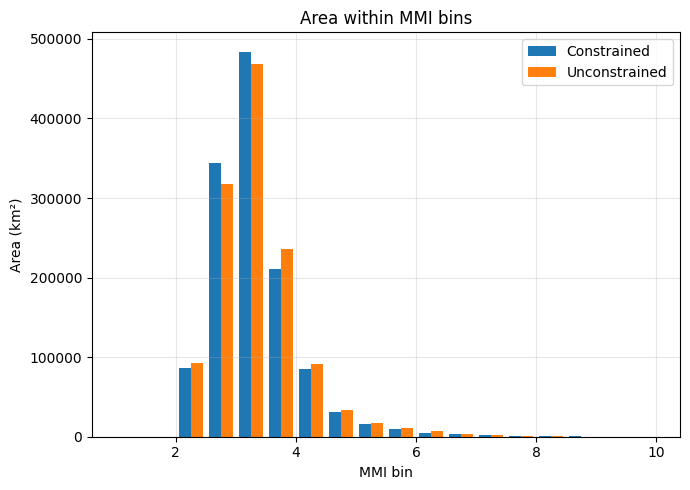

In [ ]:
# For synthetic catalogue
mag = 7.0
depth = 10

# Constrained
grid1 = f'/Users/hyin/shakemap_profiles/default/data/synth-ss_us7000pn9s/M{mag}_{depth}km_constrained/products/grid.xml'
# Unconstrained
grid2 = f'/Users/hyin/shakemap_profiles/default/data/synth-ss_us7000pn9s/M{mag}_{depth}km_unconstrained/products/grid.xml'

g1 = ShakeGrid.load(grid1).getData()[imt]
g2 = ShakeGrid.load(grid2).getData()[imt]

g1_geodict = g1.getGeoDict()
g2_geodict = g2.getGeoDict()

try:
    cutdict = g1_geodict.getBoundsWithin(g2_geodict)
except Exception:
    cutdict = g2_geodict.getBoundsWithin(g1_geodict)

# c1 and c2 are grid objects
c1 = g1.interpolateToGrid(cutdict)
c2 = g2.interpolateToGrid(cutdict)

# a1 and a2 are array objects
a1 = c1.getData()
a2 = c2.getData()
ratio = a1 / a2
dif = a1 - a2
lats = np.linspace(cutdict.ymin, cutdict.ymax, ratio.shape[0])
lons = np.linspace(cutdict.xmin, cutdict.xmax, ratio.shape[1])

bin_edges = np.arange(1.0, 10.5, 0.5)  # defines bins like [1.0–1.5), [1.5–2.0), ...

a1_bin_area, a1_bin_frac, _ = binned_area(a1, bin_edges, area_grid)
a2_bin_area, a2_bin_frac, _ = binned_area(a2, bin_edges, area_grid)

# Bin centers for plotting
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
width = (bin_edges[1] - bin_edges[0]) * 0.4

fig, ax = plt.subplots(figsize=(7,5))

ax.bar(bin_centers - width/2, a1_bin_area, width=width, label='Constrained')
ax.bar(bin_centers + width/2, a2_bin_area, width=width, label='Unconstrained')

ax.set_xlabel('MMI bin')
ax.set_ylabel('Area (km²)')
ax.set_title('Area within MMI bins')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig(f'{output}/M{mag}_{depth}km_MMI_binned_area.png', dpi=200)
# plt.close(fig)

## `sm_compare` Update

<Figure size 800x400 with 0 Axes>

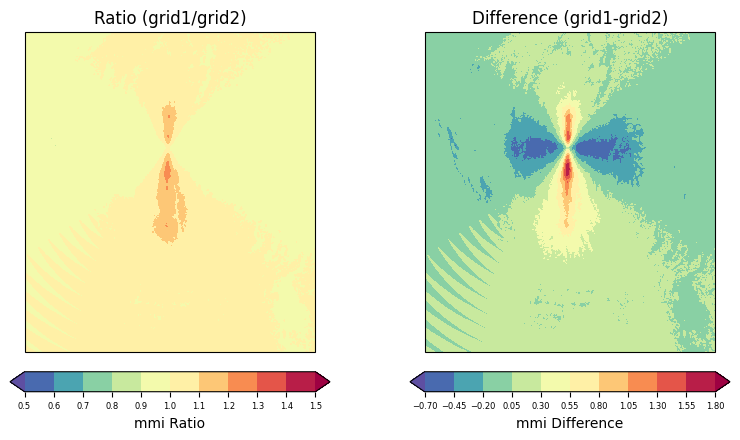

In [8]:
SIZE = (8, 4)
fig = plt.figure(figsize=SIZE)
wid = 0.4
height = 0.8

# Ratio plot
levels = list(np.linspace(0.5, 1.5, 11))
cmap = plt.cm.Spectral_r
x1 = 0.05
y1 = 0.2

fig = plt.figure(figsize=SIZE)
ax1 = plt.axes([x1, y1, wid, height], projection=ccrs.PlateCarree())
fig.subplots_adjust(left=0, right=1, bottom=0, top=1)
cs1 = ax1.contourf(lons, lats, np.flipud(ratio), levels, cmap=cmap, extend="both")
if not nocoasts:
    ax1.add_feature(cfeature.COASTLINE)

ax_cbar1 = plt.axes([x1, y1 - 0.1, wid, 0.05])
cbar1 = fig.colorbar(cs1, cax=ax_cbar1, orientation="horizontal", ticks=levels)
cbar1.ax.tick_params(labelsize=6)
cbar1.ax.set_xlabel(f"{imt} Ratio")
cbar1.ax.get_yaxis().labelpad = 15

# Difference plot
dif_min = np.min(dif)
dif_max = np.max(dif)
if dif_min != dif_max:
    levels = list(np.linspace(dif_min, dif_max, 11))
else:
    levels = list(np.linspace(-10, 10, 11))
x1 = 0.55

ax2 = plt.axes([x1, y1, wid, height], projection=ccrs.PlateCarree())
fig.subplots_adjust(left=0, right=1, bottom=0, top=1)
cs2 = ax2.contourf(lons, lats, np.flipud(dif), levels, cmap=cmap, extend="both")
if not nocoasts:
    ax2.add_feature(cfeature.COASTLINE)

ax_cbar2 = plt.axes([x1, y1 - 0.1, wid, 0.05])
cbar2 = fig.colorbar(cs2, cax=ax_cbar2, orientation="horizontal", ticks=levels)
cbar2.ax.tick_params(labelsize=6)
if imt == "pgv":
    cbar2.ax.set_xlabel(f"{imt} Difference (cm/s)")
elif imt == "stdpgv":
    cbar2.ax.set_xlabel(f"{imt} Difference (ln(cm/s))")
elif imt == "mmi" or imt == "stdmmi":
    cbar2.ax.set_xlabel(f"{imt} Difference")
elif "std" in imt:
    cbar2.ax.set_xlabel(f"{imt} Difference (ln(g))")
else:
    cbar2.ax.set_xlabel(f"{imt} Difference (percent g)")
cbar2.ax.get_yaxis().labelpad = 15

ax1.title.set_text('Ratio (grid1/grid2)')
ax2.title.set_text('Difference (grid1-grid2)')

plt.savefig(f"{output}.png", dpi=300, bbox_inches="tight")

# if __name__ == "__main__":
#     main()
